# WebSky Data Analysis
---
CMB + tSZ + noise
---

---

First of all run section 1. Pipeline. Afterwards, choose which method should be used, 2. ILC or 3. CILC, but there's no need to run 2. to be able to run 3.


---

In [15]:
### IMPORTS ###

import healpy as hp
import numpy as np
import pandas as pd
import scipy as sp
import numba as nb
import matplotlib.pyplot as plt

import gc
from joblib import Parallel, delayed
from numba import njit, prange
from scipy.interpolate import *

from astropy.wcs import WCS
from reproject import reproject_from_healpix

In [16]:
### MEMORY MANAGEMENT ###

import gc # Garbage Collector

# Before starting a new run, clear previous big variables if they exist
if 'data_cube' in locals():
    del data_cube
if 'alms_list' in locals():
    del alms_list
if 'y_hat_harmonic' in locals():
    del y_hat_harmonic

gc.collect() # Manually trigger memory cleanup

15480

In [17]:
### cosmology.py ###

omegab = 0.049
omegac = 0.261
omegam = omegab + omegac
h      = 0.68
ns     = 0.965
sigma8 = 0.81

c = 3e5

H0 = 100*h
nz = 100000
z1 = 0.0
z2 = 6.0
za = np.linspace(z1,z2,nz)
dz = za[1]-za[0]

H      = lambda z: H0*np.sqrt(omegam*(1+z)**3+1-omegam)
dchidz = lambda z: c/H(z)

chia = np.cumsum(dchidz(za))*dz

zofchi = interp1d(chia,za)

print("Cosmology set up with:")
print(f"omegab = {omegab}")
print(f"omegac = {omegac}")
print(f"omegam = {omegam}")
print(f"h = {h}")
print(f"ns = {ns}")
print(f"sigma8 = {sigma8}")

Cosmology set up with:
omegab = 0.049
omegac = 0.261
omegam = 0.31
h = 0.68
ns = 0.965
sigma8 = 0.81


## 1. PIPELINE

In [19]:
### 1. Load WebSky Components --- https://lambda.gsfc.nasa.gov/simulation/mocks_data.html --- CMB in muK units ###

# These are usually at high resolution (Nside 4096). 
# You might need to downgrade them to Nside 128 or 256 for faster testing.
path_to_websky = '/Users/joanribot/HEAVY_STUFF/TFM_data/WebSky_CMB_Mocks/'

# Set your working resolution and corresponding lmax
nside_work = 2048
#nside_work = 256

# A. Load tSZ and downgrade
y_map_raw = hp.read_map(path_to_websky + "tsz.fits")
y_map = hp.ud_grade(y_map_raw, nside_out=nside_work)

# B. Load CMB alms and let it detect the original Lmax ######### CHECK UNITS FOR CMB TOO
# Use return_mmax=True to be extra safe with WebSky's format
alms_cmb, mmax_in = hp.read_alm(path_to_websky + "unlensed_alm.fits", hdu=1, return_mmax=True)

# C. Calculate the Lmax of the file data
lmax_in = hp.Alm.getlmax(len(alms_cmb), mmax_in)

# D. Convert to map. 
# We tell it the ALMs are at 'lmax_in', but we want the result at 'nside_work'
cmb_map = hp.alm2map(alms_cmb, nside=nside_work, lmax=lmax_in, mmax=mmax_in)

In [20]:
### 2. Define the tSZ frequency scaling function and Taylor expansion ###

def get_physics_constants(nu):
    """Calculate the physics constants needed for tSZ scaling."""
    
    T_cmb = 2.7255     # CMB temperature in K
    k_B = 1.380649e-23 # Boltzmann constant in J/K
    h = 6.62607015e-34 # Planck constant in J*s
    x = (h * nu * 1e9) / (k_B * T_cmb) # Dimensionless frequency

    return x



def get_tsz_g(nu):
    """Calculate the tSZ frequency scaling g(nu) in dimensionless units."""

    x = get_physics_constants(nu)

    g_nu = x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4 # or alternatively: g_nu = x * (1 / np.tanh(x / 2)) - 4

    return g_nu



def get_tsz_f(nu):
    """Calculate the tSZ frequency scaling f(nu) in dimensionless units."""
    
    x = get_physics_constants(nu)

    f_nu = (-x/2) * ( 1 / ( (np.exp(x) - np.exp(-x)) / 2 )**2 ) # or alternatively: f_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    #f_nu = (-x/2) * (1 / np.sinh(x/2)**2)

    #f_nu_T_CMB = f_nu * T_cmb # IF DATA IN MU_K, CONVERT TO K

    return f_nu

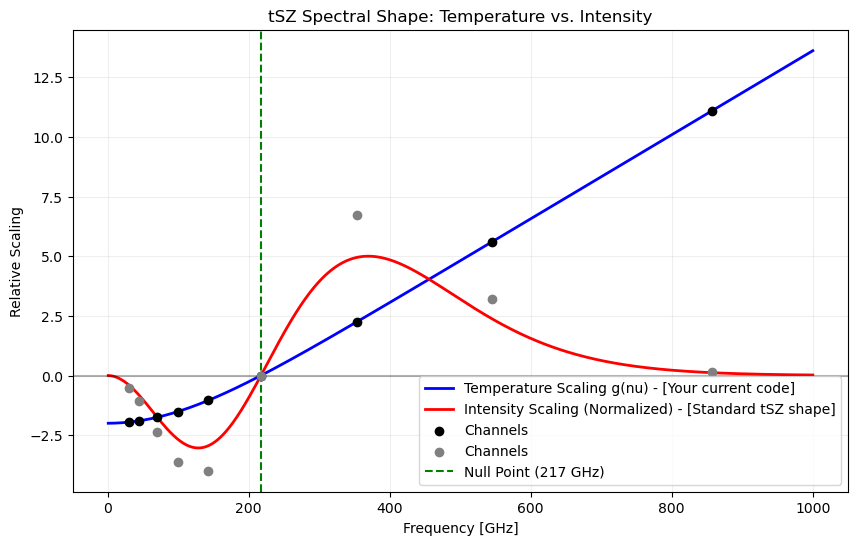

In [21]:
### 3. Compare the tSZ frequency scalings in Temperature and Intensity units ###

def get_tsz_g_temp(nu_ghz):
    """The function you currently have (Temperature units)"""
    x = get_physics_constants(nu_ghz)
    return x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4

def get_tsz_intensity_scaling(nu_ghz):
    """The Intensity distortion shape (MJy/sr units)"""
    x = get_physics_constants(nu_ghz)
    # This factor converts dT to dI
    conversion_factor = (x**4 * np.exp(x)) / (np.exp(x) - 1)**2
    return conversion_factor * get_tsz_g_temp(nu_ghz)

# Frequencies for plotting
nu = np.linspace(1, 1000, 1000)
frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] # Planck frequencies in GHz
g_temp = get_tsz_g_temp(nu)
g_int = get_tsz_intensity_scaling(nu)

# Normalize the Intensity scaling just for visual comparison
g_int_norm = g_int / np.max(np.abs(g_int))

plt.figure(figsize=(10, 6))
plt.plot(nu, g_temp, label="Temperature Scaling g(nu) - [Your current code]", color='blue', lw=2)
plt.plot(nu, g_int_norm * 5, label="Intensity Scaling (Normalized) - [Standard tSZ shape]", color='red', lw=2)

plt.scatter(frequencies, get_tsz_g(np.array(frequencies)), color='black', zorder=5, label=r"Channels")
plt.scatter(frequencies, get_tsz_intensity_scaling(np.array(frequencies)), color='gray', zorder=5, label=r"Channels")

plt.axhline(0, color='black', alpha=0.3)
plt.axvline(217, color='green', linestyle='--', label='Null Point (217 GHz)')

plt.title("tSZ Spectral Shape: Temperature vs. Intensity")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Relative Scaling")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [22]:
### 4. Calculate the noise per pixel for each frequency channel. ###

# Nside
nside_work = 2048

# Conversion factor for Compton-y to muK
T_cmb_muK = 2.7255e6

# Planck frequencies in GHz --- kickoff diapo. 8
frequencies = [30, 44, 70, 70, 100, 143, 217, 353, 545, 857]

# Reference noise
base_sensitivity_uk_arcmin = 30.0

# Calculate area of pixel in arcmin^2 for the working resolution. As hp.nside2pixarea gives us the area in steradians, we convert it to arcmin^2 by multiplying by (180*60/pi)^2
pixel_area_arcmin2 = hp.nside2pixarea(nside_work) * (180*60/np.pi)**2

print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier

    print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")


Summary of noise per pixel:
Frequency: 30 GHz, Noise per pixel: 17.46 uK
Frequency: 44 GHz, Noise per pixel: 20.96 uK
Frequency: 70 GHz, Noise per pixel: 24.45 uK
Frequency: 70 GHz, Noise per pixel: 27.94 uK
Frequency: 100 GHz, Noise per pixel: 31.44 uK
Frequency: 143 GHz, Noise per pixel: 34.93 uK
Frequency: 217 GHz, Noise per pixel: 38.42 uK
Frequency: 353 GHz, Noise per pixel: 41.92 uK
Frequency: 545 GHz, Noise per pixel: 45.41 uK
Frequency: 857 GHz, Noise per pixel: 48.90 uK


---
The data_cube should already contain all the Websky components, so maybe this is the only cell I do need to run when I restart the kernel after this session...
No, cause it doesn't contain the y_map itself, and obviously it doesn't containt the P-ILC nor the H-ILC mpaps, which are generated afterwards.
---
---

In [23]:
### 5. Read the 'data_cube' created previously, which contains the CMB+tSZ+noise at different frequencies. Each frequency is a different 'layer' in the cube. ###

print("Loading Data Cube from file...")

# field=None tells healpy to read ALL columns/frequencies at once
data_cube = hp.read_map("/Users/joanribot/HEAVY_STUFF/TFM_data/websky_data_cube_9freq.fits", field=None)

# Convert to float32 immediately to keep RAM usage low
data_cube = np.array(data_cube, dtype=np.float32)

print(f"Data Cube loaded. Shape: {data_cube.shape}") 
# Should be (9, 50331648) for Nside 2048

Loading Data Cube from file...
Data Cube loaded. Shape: (9, 50331648)


In [ ]:
### 6. Create the noise and finally the 'Data Cube' (muK units) at different frequencies ###

# Data cube structure: [N_freq, N_pix]
data_cube = []

frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] # GHz --- kickoff diapo. 8
#planck_frequencies = [143, 217, 353, 545, 857]
#component_frequencies = [40, 60, 100, 140, 166, 195, 280, 337, 402] # GHz --- kickoff diapo. 9

print(f"--- Generating Data Cube (Nside={nside_work}) ---")

for i, nu in enumerate(frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    
    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + noise_map
    data_cube.append(total_map)

data_cube = np.array(data_cube, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory

# Save all 10 frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving Data Cube to FITS... this may take a minute.")
hp.write_map("/Users/joanribot/HEAVY_STUFF/TFM_data/websky_data_cube_9freq.fits", data_cube, 
             coord='G', column_names=[f"freq_{f}" for f in frequencies],
             overwrite=True, dtype=np.float32)

print("Data Cube saved successfully as 'websky_data_cube_9freq.fits'.")

# Now 'data_cube' (muK units) is ready for your ILC functions! 

In [24]:
len(cmb_map)

50331648

### 1.2. Full data at all frequencies

Just to visualize, I think it is useful and cool ^^

In [ ]:
### MULTI-FREQUENCY GNOMVIEW ###

fig = plt.figure(figsize=(22, 8))
unit_label = r"$\mu K_{CMB}$"

# Shared parameters for all zooms
params_gnom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 400, 'hold': True, 'cmap': 'viridis', 'notext': True, 'cbar': False, 'min': -250, 'max': 250}

for i, nu in enumerate(frequencies):
    """
    Data generation
    """
    # tSZ signal in muK units for this frequency
    g_nu = get_tsz_g(nu)
    signal_tsz = g_nu * y_map * T_cmb_muK

    # Noise generation with frequency-dependent sigma
    freq_multiplier = 1.0 + (i * 0.2)
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    noise_layer = np.random.normal(0, current_sigma_pix, len(cmb_map))

    # CMB map is the same for all frequencies
    cmb_map = cmb_map  # This is already defined outside the loop
    
    # Total map = CMB + tSZ + Noise
    total_map = cmb_map + signal_tsz + noise_layer
    
    # Create subplot
    ax = fig.add_subplot(2, 5, i+1)
    
    # Plot map
    hp.gnomview(total_map, **params_gnom)
    
    # Add title manually with matplotlib for better spacing
    plt.title(f"{nu} GHz", fontsize=16, pad=10)

# Add a single colorbar at the bottom for the whole figure
# [left, bottom, width, height]
cax = fig.add_axes([0.25, 0.05, 0.5, 0.03])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=-250, vmax=250))
cb = plt.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_label(unit_label, fontsize=14)

plt.suptitle("Total Observed Signals (Zoomed) - Frequency Evolution", fontsize=22, y=1.02)
plt.subplots_adjust(hspace=0.4, wspace=0.1)
plt.show()

In [ ]:
### MULTI-FREQUENCY MOLLVIEW ###

fig = plt.figure(figsize=(22, 9))
unit_label = r"$\mu K_{CMB}$"

# Shared parameters for all mollviews
params_moll = {'hold': True, 'cmap': 'viridis', 'notext': True, 'cbar': False, 'min': -300, 'max': 300}

for i, nu in enumerate(frequencies):
    """
    Data generation
    """
    # tSZ signal in muK units for this frequency
    g_nu = get_tsz_g(nu)
    signal_tsz = g_nu * y_map * T_cmb_muK

    # Noise generation with frequency-dependent sigma
    freq_multiplier = 1.0 + (i * 0.2)
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    noise_layer = np.random.normal(0, current_sigma_pix, len(cmb_map))

    # CMB map is the same for all frequencies
    cmb_map = cmb_map  # This is already defined outside the loop
    
    # Total map = CMB + tSZ + Noise
    total_map = cmb_map + signal_tsz + noise_layer
    
    # Create subplot
    ax = fig.add_subplot(3, 4, i+1)
    
    # Plot map
    hp.mollview(total_map, **params_moll)
    
    # Add title manually with matplotlib for better spacing
    plt.title(f"{nu} GHz", fontsize=16, pad=10)

# Add a single colorbar at the bottom for the whole figure
# [left, bottom, width, height]
cax = fig.add_axes([0.25, 0.05, 0.5, 0.03])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=-250, vmax=250))
cb = plt.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_label(unit_label, fontsize=14)

plt.suptitle("Total Observed Signals (full sky) - Frequency Evolution", fontsize=22, y=1.02)
plt.subplots_adjust(hspace=0.4, wspace=0.1)
plt.show()

## 2. ILC

### Outline 

2.1. ILC method definition

2.2. ILC processing and comparison (Pixel & Harmonic): $g(\nu)$

2.3. PILC & HILC plots

### 2.1. ILC method definition

In [25]:
def run_pixel_ilc(data_cube, g_vector_muK): ### UNITLESS MAP OUTPUT + WEIGHTS ###

    # C definition
    n_freq, n_pix = data_cube.shape
    C = (1.0 / n_pix) * (data_cube @ data_cube.T) # IS IT THAT d_i (p') * d_j (p') = data_cube @ data_cube.T
    C_inv = np.linalg.pinv(C)

    # Calculate the weights
    weights = (C_inv @ g_vector_muK) / (g_vector_muK.T @ C_inv @ g_vector_muK)

    return weights @ data_cube, weights

# weights @ data_cube IS UNITLESS AS [weights] = 1/g^t * data_cube = 1/T_cmb * T_cmb
# [g] = T_cmb_muK
# [data_cube] = T_cmb_muK

In [ ]:
def run_harmonic_ilc_with_weights(data_cube, g_vector, l_bins): ### UNITLESS MAP OUTPUT + WEIGHTS PER BIN  ###
    """Advanced Harmonic-Space ILC (Multi-scale)"""
    n_freq, n_pix = data_cube.shape
    nside = hp.npix2nside(n_pix)
    lmax = 3*nside-1
    alms_list = [hp.map2alm(m, lmax=lmax) for m in data_cube]
    final_alms = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
    ell, _ = hp.Alm.getlm(lmax)
    
    # NEW: Matrix to store weights for each bin
    weights_per_bin = []

    for i in range(len(l_bins)-1):
        mask = (ell >= l_bins[i]) & (ell < l_bins[i+1])
        bin_alms = np.array([alms[mask] for alms in alms_list])
        cov_bin = np.real(np.conj(bin_alms) @ bin_alms.T) / np.sum(mask)
        inv_cov = np.linalg.pinv(cov_bin)
        
        # Calculate weights for THIS specific scale
        w_bin = (inv_cov @ g_vector) / (g_vector.T @ inv_cov @ g_vector)
        weights_per_bin.append(w_bin) # Store them
        
        final_alms[mask] = w_bin @ bin_alms
        
    return hp.alm2map(final_alms, nside=nside), np.array(weights_per_bin)

### 2.2. ILC processing and comparison (Pixel & Harmonic): $g(\nu)$

Execute both methods separetly for the seek of time. Harmonic-space is more time consuming as more bins are considered.

In [26]:
### Previous to the methods: T_cmb_muK & g_vector_muK ###

# Conversion factor for Compton-y to muK
T_cmb_muK = 2.7255e6

# Planck frequencies in GHz --- kickoff diapo. 8
frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857]

# Define g_vector (and f_vector) in muK units for the frequencies in the data cube
g_vector_muK = np.array([get_tsz_g(nu) for nu in frequencies]) * T_cmb_muK # IT HAS TO BE MULTIPLIED BY T_CMB * 10^6 or T_CMB_MU_K

# If we wanted to do the same for f_vector (for the tSZ-only ILC), we would do:
#f_vector_muK = np.array([get_tsz_f(nu) for nu in frequencies]) * T_cmb_muK

In [27]:
### P-ILC ###

# Run P-ILC. The resulting map is unitless.
y_hat_pixel, weights_pixel = run_pixel_ilc(data_cube, g_vector_muK)

# Calculate the residual in dimensionless y units (Truth - Reconstruction)
residual_pixel = y_map - y_hat_pixel


"""
# As y_map is also unitless, I will leave both unitless. However, I could aslo convert both to muK units and have a 10^5 scale factor.
y_map_muK = y_map * T_cmb_muK
residual_pixel_muK = y_map_muK - y_hat_pixel * T_cmb_muK
"""

# Validation: Both should be order 10^-5
print(f"Truth max: {np.max(y_map):.2e}")
print(f"Reco max: {np.max(y_hat_pixel):.2e}")

Truth max: 1.99e-04
Reco max: 2.01e-04


In [28]:
### ILC ANALYSIS WEIGHTS FOR PIXEL_ILC ###

df_weights_pixel_ilc = pd.DataFrame({
    'Freq (GHz)': frequencies,
    #'Weight': weights_pixel_ilc
    'Weight': weights_pixel,
    'g(nu) * T_cmb_muK': g_vector_muK
})
# Transpose it for horizontal display
df_horizontal_pixel_ilc = df_weights_pixel_ilc.set_index('Freq (GHz)').T
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)
print("--- ILC Analysis Weights ---")
print(df_horizontal_pixel_ilc)
print()

# Verify the constraint is satisfied
constraint_check_pixel_ilc = np.sum(weights_pixel * g_vector_muK)
weights_pixel_sum = np.sum(weights_pixel)
print(f"Constraint Check: {constraint_check_pixel_ilc:.4f}")
print(f"Sum of Weights: {weights_pixel_sum:.4f}")
print("Great! Since the CMB has the same value in every channel, the ILC 'subtracts' the low-frequency channels from the high-frequency ones to make the CMB disappear.")

--- ILC Analysis Weights ---
Freq (GHz)                  30            44            70            100           143           217           353           545           857
Weight            -1.584705e-08 -1.060360e-08 -6.960455e-09 -4.228915e-09 -1.721799e-09  1.504904e-09  6.449241e-09  1.196039e-08  1.929767e-08
g(nu) * T_cmb_muK -5.324823e+06 -5.181010e+06 -4.777716e+06 -4.110328e+06 -2.835511e+06 -2.119107e+04  6.107144e+06  1.525743e+07  3.022754e+07

Constraint Check: 1.0000
Sum of Weights: -0.0000
Great! Since the CMB has the same value in every channel, the ILC 'subtracts' the low-frequency channels from the high-frequency ones to make the CMB disappear.


In [ ]:
### H-ILC (with weights) ###
l_bins = [2, 25, 50, 75, 100, 150, 200, 300, 500, 1000]

# Calculate the harmonic ILC reconstruction and get the weights for each bin
y_hat_harmonic, weights_harmonic_bins = run_harmonic_ilc_with_weights(data_cube, g_vector_muK, l_bins)

# Residual map in muK units for harmonic ILC
residual_harmonic = y_map - y_hat_harmonic


"""
Again, I could convert both to muK units and have a 10^5 scale factor, but I will leave them unitless for consistency with the pixel ILC.
y_map_muK = y_map * T_cmb_muK
residual_harmonic = y_map_muK - y_hat_harmonic * T_cmb_muK
"""

# Validation: Both should be order 10^-5
print(f"Truth max: {np.max(y_map):.2e}")
print(f"Reco max: {np.max(y_hat_harmonic):.2e}")

### 2.3. PILC & HILC plots

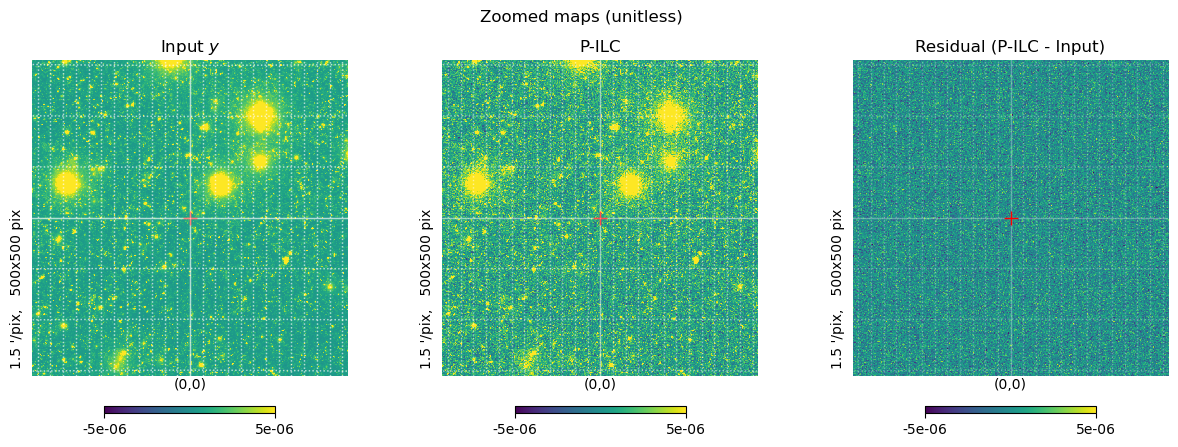

In [29]:
### A.1. PIXEL ILC ZOOMED MAPS ###

# Define units: use 'r' before strings to avoid SyntaxWarnings with LaTeX \mu
#unit_label = r"$\mu K_{CMB}$" ### WE ARE NOT USING THEM THO!!! u sure? YES

params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': False, 'min': -5*10**-6, 'max': 5*10**-6}
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 3, 1)
hp.gnomview(y_map, title="Input $y$", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.gnomview(y_hat_pixel, title="P-ILC", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.gnomview(residual_pixel, title="Residual (P-ILC - Input)", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Zoomed maps (unitless)")
plt.savefig("Figures/PILC_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

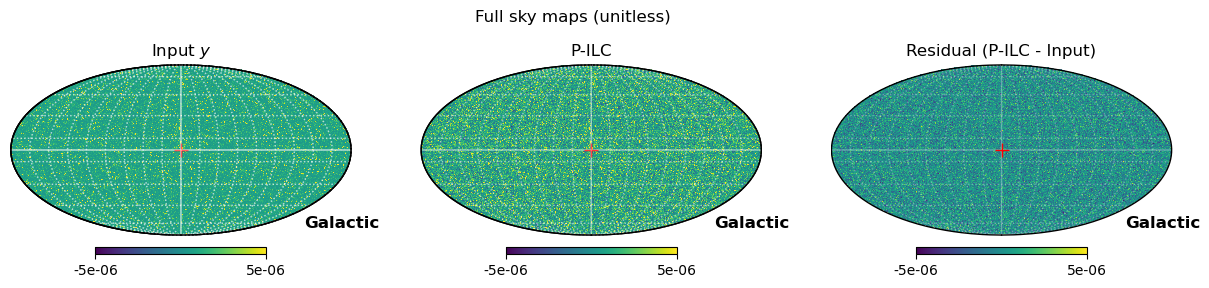

In [30]:
### A.2. PIXEL ILC FULL SKY MAPS ###

params_moll = {'coord': ['G'], 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': False, 'min': -5*10**-6, 'max': 5*10**-6}
#params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 3))

ax1 = plt.subplot(1, 3, 1)
hp.mollview(y_map, title="Input $y$", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.mollview(y_hat_pixel, title="P-ILC", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.mollview(residual_pixel, title="Residual (P-ILC - Input)", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Full sky maps (unitless)")
plt.savefig("Figures/PILC_full_sky_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

ValueError: Could not determine whether the data follows the 'ring' or 'nested' ordering, so you should set nested=True or nested=False explicitly.

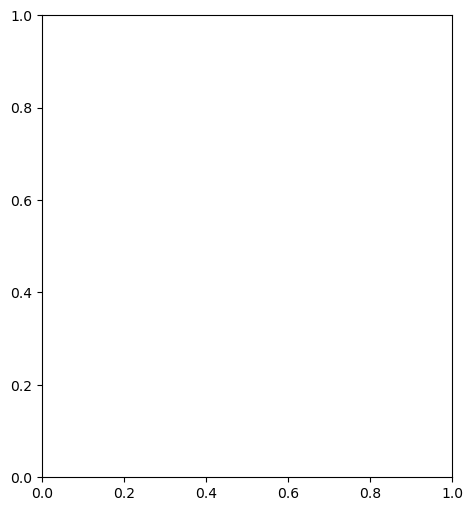

In [31]:
### A.3. PIXEL ILC WITH ASTROPY WCS PROJECTION (Zoomed) ###

def plot_with_astropy(hp_map, rot, reso_arcmin, xsize, title, vmin=-5e-6, vmax=5e-6):
    """
    Plots a HEALPix map using Astropy WCS projection.
    rot: [lon, lat] in degrees
    reso_arcmin: resolution in arcminutes
    xsize: number of pixels
    """
    # 1. Create the WCS header for Gnomonic projection (TAN)
    # We set the center of the image to your 'rot' coordinates
    wcs = WCS(naxis=2)
    wcs.wcs.crpix = [xsize / 2, xsize / 2] # Center of image
    wcs.wcs.cdelt = [-reso_arcmin/60., reso_arcmin/60.] # Resolution in degrees
    wcs.wcs.crval = [rot[0], rot[1]] # Galactic coordinates from 'rot'
    wcs.wcs.ctype = ["GLON-TAN", "GLAT-TAN"] # Galactic Longitude/Latitude
    
    # 2. Reproject HEALPix map to this WCS
    # This replaces hp.gnomview logic with high-quality interpolation
    array, footprint = reproject_from_healpix((hp_map, 'galactic'), 
                                              wcs, shape_out=(xsize, xsize))

    # 3. Plot using Matplotlib + WCSAxes
    ax = plt.gca(projection=wcs)
    im = ax.imshow(array, vmin=vmin, vmax=vmax, cmap='viridis', origin='lower')
    
    # Add coordinate grid and labels
    ax.coords.grid(color='white', alpha=0.5, linestyle='solid')
    ax.coords[0].set_axislabel('Galactic Longitude')
    ax.coords[1].set_axislabel('Galactic Latitude')
    
    # Show the (l, b) center in the title as requested
    ax.set_title(f"{title}\nCenter: (l={rot[0]}°, b={rot[1]}°)", fontsize=12)
    
    return im

# --- Calling the function for your 3 maps ---
fig = plt.figure(figsize=(18, 6))

# Define your rotation and resolution
my_rot = [45, -30] # Your cluster location
res = 1.5
sz = 500

plt.subplot(131, projection=None) # projection handled inside function
plot_with_astropy(y_map, my_rot, res, sz, "Input y")

plt.subplot(132)
plot_with_astropy(y_hat_pixel, my_rot, res, sz, "P-ILC")

plt.subplot(133)
plot_with_astropy(residual_pixel, my_rot, res, sz, "Residual")

plt.tight_layout()
plt.show()

In [ ]:
### B.1. HARMONIC ILC ZOOMED MAPS ###

params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True, 'min': -5*10**-6, 'max': 5*10**-6}
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 600, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
#hp.gnomview(y_map_muK, title="Harmonic ILC: Full Sky (y)", **params_zoom)
hp.gnomview(y_map, title="Input $y$", **params_zoom)

plt.subplot(1, 3, 2)
#hp.gnomview(y_hat_harmonic_muK, title="H-ILC", **params_zoom) ### NEXT TIME U COMPILE REMEMBER TO SWAP, I JUST SWAPED NAMES (_muK)
hp.gnomview(y_hat_harmonic, title="H-ILC", **params_zoom)

plt.subplot(1, 3, 3)
#hp.gnomview(residual_harmonic_muK, title="Harmonic ILC: Residual (Truth - Reco)", **params_zoom)
hp.gnomview(residual_harmonic, title="Residual (H-ILC - Input)", **params_zoom)

plt.suptitle("Harmonic-Space ILC. Zoomed maps (unitless)")
plt.savefig("Figures/HILC_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### B.2. HARMONIC ILC FULL SKY MAPS ###

params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True, 'min': -5*10**-6, 'max': 5*10**-6}
#params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 3))

plt.subplot(1, 3, 1)
#hp.mollview(y_map_muK, title="Harmonic ILC: Full Sky (y)", **params_moll)
hp.mollview(y_map, title="Input $y$", **params_moll)

plt.subplot(1, 3, 2)
#hp.mollview(y_hat_harmonic_muK, title="Harmonic ILC: Reconstruction", **params_moll) ### NEXT TIME U COMPILE REMEMBER TO SWAP, I JUST SWAPED NAMES (_muK)
hp.mollview(y_hat_harmonic, title="H-ILC", **params_moll)

plt.subplot(1, 3, 3)
#hp.mollview(residual_harmonic_muK, title="Harmonic ILC: Residual (Truth - Reco)", **params_moll)
hp.mollview(residual_harmonic, title="Residual (H-ILC - Input)", **params_moll)

plt.suptitle("Harmonic-Space ILC. Full sky maps (unitless)")
plt.savefig("Figures/HILC_full_sky_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### B.3. HARMONIC WEIGHTS EVOLUTION ###

plt.figure(figsize=(10, 6))

# Define labels for the x-axis bins
bin_labels = [f"{l_bins[i]}-{l_bins[i+1]}" for i in range(len(l_bins)-1)]

for f_idx, nu in enumerate(frequencies):
    plt.plot(bin_labels, weights_harmonic_bins[:, f_idx], label=f"{nu} GHz", marker='o', linewidth=2)

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel(rf"Multipole Scale ($\ell$ bin)")
plt.ylabel("H-ILC Weight")
plt.title("Harmonic ILC weights evolution across scales")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig("Figures/HILC_weights_evolution.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### ZOOMED VISUALIZATION OF INDIVIDUAL COMPONENTS ###

# 1. Choose the frequency to inspect
# Index 0 is 30 GHz in frequencies = [30, 44, 70, 70, 100, 143, 217, 353, 545, 857]
nu_idx = 7
nu_val = frequencies[nu_idx]

# 2. Calculate proper Scaling and Constants
g_nu = get_tsz_g(nu_val)
T_cmb_muK = 2.7255e6 

# 3. Calculate the proper Noise Sigma for this channel
# Using the Nside-dependent scaling and the frequency multiplier
freq_noise_multiplier = 1.0 + (nu_idx * 0.2)
base_sensitivity_uk_arcmin = 30.0
current_S = base_sensitivity_uk_arcmin * freq_noise_multiplier
pixel_area_arcmin2 = hp.nside2pixarea(nside_work) * (180*60/np.pi)**2
print(f"Frequency: {nu_val} GHz, Frequency Noise Multiplier: {freq_noise_multiplier:.2f}, Current S (uK-arcmin): {current_S:.2f} uK-arcmin, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)


# 4. Generate the Layers
# Layer A: Primary CMB (loaded from WebSky)
# Layer B: tSZ Signal
signal_tsz = g_nu * y_map * T_cmb_muK
# Layer C: Proper Noise (Zero-mean, proper sigma)
noise_layer = np.random.normal(0, current_sigma_pix, len(cmb_map))
# Layer D: Total Map
total_map = cmb_map + signal_tsz + noise_layer

# 5. Plotting (2x2 Grid)
fig = plt.figure(figsize=(16, 10))
# reso: for Nside 2048, 1.5 arcmin per pixel.
# rot: center on [0,0] or a specific cluster
params = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True, 'min': -100, 'max': 100} # 'min': -200, 'max': 200 --- FOR COMPARING THE INTENSITY OF THE COMPONENTS WITH THE SAME COLOR SCALE (uK)


# Use 'r' before strings to avoid SyntaxWarnings with LaTeX \mu
unit_label = r"$\mu K_{CMB}$"

# --- Plotting ---

# Subplot 1: The CMB
plt.subplot(2, 2, 1)
hp.gnomview(cmb_map, title="1. Primary CMB", unit=unit_label, **params)

# Subplot 2: The tSZ Signal (Changes with frequency)
plt.subplot(2, 2, 2)
hp.gnomview(signal_tsz, title=rf"2. tSZ Signal ({nu_val} GHz)", unit=unit_label, **params)

# Subplot 3: Proper Instrumental Noise
plt.subplot(2, 2, 3)
hp.gnomview(noise_layer, title="3. Instrumental Noise", unit=unit_label, **params)

# Subplot 4: The Total Map (What the telescope sees)
plt.subplot(2, 2, 4)
hp.gnomview(total_map, title=rf"4. TOTAL Observed ({nu_val} GHz)", unit=unit_label, **params)

plt.suptitle(f"Frequency Channel Breakdown: {nu_val} GHz", fontsize=18, y=0.95)
plt.show()

In [ ]:
### MOLLWEIDE VIEW OF INDIVIDUAL COMPONENTS ###

# 5. Plotting (2x2 Grid)
fig = plt.figure(figsize=(16, 10))
# reso: for Nside 2048, 1.7 arcmin per pixel
# rot: center on [0,0] or a specific cluster
params = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True, 'min': -100, 'max': 100} # 'min': -200, 'max': 200 --- FOR COMPARING THE INTENSITY OF THE COMPONENTS WITH THE SAME COLOR SCALE (uK)


# Use 'r' before strings to avoid SyntaxWarnings with LaTeX \mu
unit_label = r"$\mu K_{CMB}$"

# --- Plotting ---

# Subplot 1: The CMB
plt.subplot(2, 2, 1)
hp.mollview(cmb_map, title="1. Primary CMB", unit=unit_label, **params)

# Subplot 2: The tSZ Signal (Changes with frequency)
plt.subplot(2, 2, 2)
hp.mollview(signal_tsz, title=rf"2. tSZ Signal ({nu_val} GHz)", unit=unit_label, **params)

# Subplot 3: Proper Instrumental Noise
plt.subplot(2, 2, 3)
hp.mollview(noise_layer, title="3. Instrumental Noise", unit=unit_label, **params)

# Subplot 4: The Total Map (What the telescope sees)
plt.subplot(2, 2, 4)
hp.mollview(total_map, title=rf"4. TOTAL Observed ({nu_val} GHz)", unit=unit_label, **params)

plt.suptitle(f"Frequency Channel Breakdown: {nu_val} GHz", fontsize=18, y=0.95)
plt.show()

## 3. Constrained ILC

To run this section I think it is not necessary to run section 2. as the new variables can be defined again...

But they have to be defined again (g_vector, etc.) if section 2 is not run.

---
The goal of this section is to get the $\mu y$ map.
---
---

### Outline 

3.1. CILC method definition

3.2. CILC processing and comparison (Pixel & Harmonic): $f(\nu)$

3.3. P-CILC & H-CILC plots

### 3.1. CILC definitions

In [ ]:
def run_pixel_cilc(data_cube, g_vector_muK, f_vector_muK):
    """
    Constrained ILC to extract tSZ while explicitly nulling the CMB.
    - g_tsz: tSZ frequency response (e.g., g_vector_muK)
    - f_tsz: tSZ frequency response (usually np.ones(n_freq))
    """

    n_freq, n_pix = data_cube.shape

    # 1. Compute Covariance Matrix
    C = (1.0 / n_pix) * (data_cube @ data_cube.T)
    C_inv = np.linalg.pinv(C)

    # Maybe we do need another "C" and then "C_inv" for operating the f_vector
    # I THINK IT'S NOT NECESSARY, I CAN USE THE SAME C... CHECK ANYWAYS

    # 2. Define the Constraint Matrix A and target vector e
    # A is (n_freq x 2), e is (2 x 1)
    A = np.column_stack((g_vector_muK, f_vector_muK))
    e = np.array([1.0, 0.0]) # 1 for tSZ, 0 for CMB

    # 3. Calculate CILC weights: w = C_inv * A * (A^T * C_inv * A)^-1 * e
    # Intermediate term: (A^T * C_inv * A)

    #weights = (C_inv @ A @ np.linalg.inv(A.T @ C_inv @ A) @ e) # extra terms here !!!
    
    inv_matrix = np.linalg.inv(A.T @ C_inv @ A)
    weights = C_inv @ A @ inv_matrix @ e
    
    # 4. Apply weights
    y_hat_cilc = weights @ data_cube
    
    return y_hat_cilc, weights

In [ ]:
def run_harmonic_cilc_with_weights(data_cube, g_vector, f_vector, l_bins):
    """Advanced Harmonic-Space ILC (Multi-scale)"""
    n_freq, n_pix = data_cube.shape
    nside = hp.npix2nside(n_pix)
    lmax = 3*nside-1
    alms_list = [hp.map2alm(m, lmax=lmax) for m in data_cube]
    final_alms = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
    ell, _ = hp.Alm.getlm(lmax)
    
    # NEW: Matrix to store weights for each bin
    weights_per_bin = []

    for i in range(len(l_bins)-1):
        # g_vector block:
        mask = (ell >= l_bins[i]) & (ell < l_bins[i+1])
        bin_alms = np.array([alms[mask] for alms in alms_list])
        cov_bin = np.real(np.conj(bin_alms) @ bin_alms.T) / np.sum(mask)
        inv_cov = np.linalg.pinv(cov_bin)

        # f_vector block:
        
        
        # Calculate weights for THIS specific scale
        w_bin = (inv_cov @ g_vector) / (g_vector.T @ inv_cov @ g_vector) # extra terms here !!!
        weights_per_bin.append(w_bin) # Store them
        
        final_alms[mask] = w_bin @ bin_alms
        
    return hp.alm2map(final_alms, nside=nside), np.array(weights_per_bin)

In [ ]:

# Conversion factor for Compton-y to muK
T_cmb_muK = 2.7255e6

# Define g_vector (and f_vector) in muK units for the frequencies in the data cube
g_vector_muK = np.array([get_tsz_g(nu) for nu in frequencies]) * T_cmb_muK # IT HAS TO BE MULTIPLIED BY T_CMB * 10^6 or T_CMB_MU_K
f_vector_muK = np.array([get_tsz_f(nu) for nu in frequencies]) * T_cmb_muK # IT HAS TO BE MULTIPLIED BY T_CMB * 10^6 or T_CMB_MU_K

# If we wanted to do the same for f_vector (for the tSZ-only ILC), we would do:
#f_vector_muK = np.array([get_tsz_f(nu) for nu in frequencies]) * T_cmb_muK

NOTATION: add an extra _f to all previous variables

In [ ]:
### 4. NEW 'Data Cube' for CILC (at different frequencies) ###

# Data cube structure: [N_freq, N_pix]
data_cube_f = []

frequencies = [30, 44, 70, 70, 100, 143, 217, 353, 545, 857] # GHz --- kickoff diapo. 8
#planck_frequencies = [143, 217, 353, 545, 857]
#component_frequencies = [40, 60, 100, 140, 166, 195, 280, 337, 402] # GHz --- kickoff diapo. 9

# Conversion factor for Compton-y to muK
T_cmb_muK = 2.7255e6

# Reference noise
base_sensitivity_uk_arcmin = 30.0

# Calculate area of pixel in arcmin^2 for the working resolution. As hp.nside2pixarea gives us the area in steradians, we convert it to arcmin^2 by multiplying by (180*60/pi)^2
pixel_area_arcmin2 = hp.nside2pixarea(nside_work) * (180*60/np.pi)**2

# mu variable
mu = [] # ?

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier

    print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    f_nu = get_tsz_f(nu)
    
    # Signal tSZ en muK
    signal_tsz_f = g_nu * y_map * T_cmb_muK   +    mu * f_nu * y_map * T_cmb_muK
    
    # Noise realization (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise
    total_map = cmb_map + signal_tsz_f + noise_map
    data_cube.append(total_map)

data_cube_f = np.array(data_cube_f)

# Now 'data_cube' is ready for your ILC functions!

### 3.2. CILC processing and comparison (Pixel & Harmonic): $f(\nu)$

In [ ]:
### EXECUTE BOTH METHODS ###

# Conversion factor for Compton-y to muK
T_cmb_muK = 2.7255e6

# Define the f_vector in muK units for the frequencies in the data cube
#g_vector_muK = np.array([get_tsz_g(nu) for nu in frequencies]) * T_cmb_muK # ALREADY DEFINED!
f_vector_muK = np.array([get_tsz_f(nu) for nu in frequencies]) * T_cmb_muK # IT HAS TO BE MULTIPLIED BY T_CMB * 10^6 or T_CMB_MU_K

### Pixel ILC ###
y_hat_pixel_muK_f, weights_pixel_f = run_pixel_cilc(data_cube, g_vector_muK, f_vector_muK)

# Convert y_map to muK units for comparison
y_map_mu = y_map * T_cmb_muK

# Residual map in muK units for pixel ILC
residual_pixel_f = y_map_muK - y_hat_pixel_muK_f



### Harmonic ILC (with weights) ###
l_bins = [2, 25, 50, 75, 100, 150, 200, 300, 500, 1000]

# Calculate the harmonic ILC reconstruction and get the weights for each bin
y_hat_harmonic_muK_f, weights_harmonic_bins_f = run_harmonic_ilc_with_weights(data_cube_f, g_vector_muK, f_vector_muK l_bins)

# Residual map in muK units for harmonic ILC
residual_harmonic_f = y_map_muK - y_hat_harmonic_muK_f

### 3.3. P-CILC & H-CILC plots

## 4. CMB maps

### Outline

3 gnomviews & 3 mollviews of the CMB, with a = [1,...,1]

y_cmb, y_ILC_cmb, y_cmb_residuals

Maybe I could have done it before section 3. as this is apparently easier.

### Intent antic per CMB, modificar-lo i fer-ho amb el nou codi!

In [ ]:
# Let's do the same for the CMB component to see how well we can recover it (though we didn't explicitly target it, it's interesting to check)
# For CMB, the g-vector is just [1, 1, 1, 1, 1] since CMB is constant across frequencies in thermodynamic units

T_cmb_muK = 2.73e6 # muK

g_vector_cmb = np.ones(len(frequencies)) * T_cmb_muK  ### per microK!!! EL MATEIX QUE AMB y MAP, LES UNITATS HAN DE SER LES MATEIXES PER TOTS ELS MAPES PER PODER OPERARLOS!!!
cmb_reconstructed_pixel = run_pixel_ilc(data_cube, g_vector_cmb)[0]
cmb_reconstructed_harmonic = run_harmonic_ilc_with_weights(data_cube, g_vector_cmb, lbins)

# Calculate residuals for tSZ
residual = y_map - y_reconstructed_pixel
residual_harmonic = y_map - y_reconstructed_harmonic
bias = np.mean(residual)

# And plot the residuals to see where the methods struggle the most. This can highlight if there are specific regions (e.g., around clusters) where one method outperforms the other.
fig = plt.figure(figsize=(18, 6))
params = {'rot': [0, 0], 'reso': 15, 'xsize': 400, 'hold': True}

# Subplot 1: The "Truth" (The y_map we want to recover)
plt.subplot(1, 3, 1)
hp.gnomview(cmb_map, title="Target: WebSky CMB", **params)

# Subplot 2: Result from Pixel ILC
plt.subplot(1, 3, 2)
hp.gnomview(cmb_reconstructed_pixel, title="Recovered: Pixel ILC", **params)

# Subplot 3: Result from Harmonic ILC
plt.subplot(1, 3, 3)
hp.gnomview(cmb_reconstructed_harmonic, title="Recovered: Harmonic ILC", **params)

plt.show()

pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)
print(f"Optimal Weights (Pixel ILC): {weights_pixel}")

In [ ]:
microK

sqrt 4pi / 12*Nside^2 * 180/pi * 60 i ja ho tenim en arcmin

In [ ]:
print(np.sqrt((4*np.pi)/(12*128**2)) * 180 / np.pi * 60)
print(np.sqrt((4*np.pi)/(12*2048**2)) * 180 / np.pi * 60)

In [ ]:
2/27.48 # això ´és la rms DEL NOISE PER nSIDE 128

In [ ]:
RESIDUALS PER CMB TOO

C localitzat, no mitja global

### Residuals

In [ ]:
### RESIDUAL ANALYSIS - Gemini ###

# Calculate Residual (Truth - Reconstruction)
residual = y_map - y_reconstructed_pixel

residual_harmonic = y_map - y_reconstructed_harmonic

fig = plt.figure(figsize=(15, 6))
params = {'rot': [0, 0], 'reso': 15, 'xsize': 400, 'hold': True}

# Plot the Reconstruction
plt.subplot(1, 2, 1)
hp.gnomview(y_reconstructed_pixel, title="Recovered tSZ (y)", **params)


# Plot the Residual
#plt.subplot(1, 2, 2)
#hp.gnomview(residual, title="Residual (Truth - Recovered)", **params)
#
# Plot the Reconstruction for harminoic
plt.subplot(1, 2, 2)
hp.gnomview(residual_harmonic, title="Recovered tSZ (y) - Harmonic", **params)

plt.show()

# Calculate Numerical Metrics
bias = np.mean(residual)
std_resid = np.std(residual)
print(f"Residual Mean (Bias): {bias:.2e}")
print(f"Residual Std Dev (Noise Level): {std_resid:.2e}")

bias2 = np.mean(residual_harmonic)
std_resid2 = np.std(residual_harmonic)
print(f"Residual Mean (Bias) - Harmonic: {bias2:.2e}")
print(f"Residual Std Dev (Noise Level) - Harmonic: {std_resid2:.2e}")

In [ ]:
### RESIDUAL ANALYSIS - Autocomplete ###

# Compute residuals for each method
residual_pixel = y_map - y_reconstructed_pixel
residual_harmonic = y_map - y_reconstructed_harmonic

# Plot residuals
fig = plt.figure(figsize=(18, 6))
params = {'rot': [0, 0], 'reso': 15, 'xsize': 400, 'hold': True, 'min': -1e-6, 'max': 1e-6}  # Adjust min/max for better contrast

# Subplot 1: Residual from Pixel ILC
plt.subplot(1, 3, 1)
hp.gnomview(residual_pixel, title="Residual: Pixel ILC", **params)

# Subplot 2: Residual from Harmonic ILC
plt.subplot(1, 3, 2)
hp.gnomview(residual_harmonic, title="Residual: Harmonic ILC", **params)

# Subplot 3: Difference between residuals (to see where one is better than the other)
diff_residuals = residual_pixel - residual_harmonic
plt.subplot(1, 3, 3)
hp.gnomview(diff_residuals, title="Difference of Residuals", **params)

plt.show()

PLOT ON THE SAME SCALES FOR BETTER COMPARISON

en una zona localitzada its better the pixel ilc que harmonic, però si fessim només cmb podria ser al revés

monopols l? FEIM L = 0 PER CMB!!!

Low monopoles l perform better in harmonic space, but might have more noise at small scales. The difference plot can highlight specific regions where one method outperforms the other.

In [ ]:
# Low monopoles l perform better in harmonic space, but might have more noise at small scales. The difference plot can highlight specific regions where one method outperforms the other.

In [ ]:
### WEIGHTS ANALYSIS ###

# Create a nice table for the weights
df_weights = pd.DataFrame({
    'Frequency (GHz)': frequencies,
    'g_nu (Scaling)': g_vector,
    'ILC Weight': weights_pixel
})

print("--- ILC Analysis Weights ---")
print(df_weights.to_string(index=False))

# Optional: Plot the weights to see which frequency 'contributes' most
df_weights.plot(x='Frequency (GHz)', y='ILC Weight', kind='bar', color='teal')
plt.title("Contribution of each Frequency to the ILC Map")
plt.ylabel("Weight Value")
plt.show()

## WebSky model

See https://github.com/simonsobs/websky_model.git for documentation.

I can't even find or install $\textit{websky}$ nor $\textit{websky\_model}$  libraries, so just IGNORE.

In [ ]:
import numpy as np
import websky_model as wm
import websky as ws

# load model
wmodel = wm.WebSky(directory_path='/global/project/projectdirs/sobs/v4_sims/mbs/websky/data/',websky_version = 'v0.1', verbose=True)

# read in halo catalogue
hcat  = wmodel.load_halo_catalogue(mmin=0, mmax=np.inf, zmin=0, zmax=np.inf, rmin=0., rmax=np.inf, practical=True)

# project halos onto healpix map. 
# each halo is given a "flux" of weight=constant, or weight=array(len(Nhalo))
hpmap = wmodel.catalogue_to_map(hcat, nside=512, weight=1)

# get cib map filename
fname_cib = wmodel.cib_map_file_name(freq='545')

fname_kappa = wmodel.kappa_map_file_name()

# get compton-y map filename
fname_comptony = wmodel.comptony_map_file_name()